<a href="https://colab.research.google.com/github/saurabhsinghyadavgit/land-sliding/blob/main/land_slide_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q kaggle


In [ ]:
from google.colab import files
files.upload()


Saving kaggle (7).json to kaggle (7).json


{'kaggle (7).json': b'{"username":"jatins4567890","key":"ce4b55040ac4cde7ea7a1f4826f68a6f"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp 'kaggle (7).json' ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
! kaggle.com/datasets/vigneshwarchandran/landslide-data-large-numeric?select=new1SupervisedDataSet.csqerwiuPOv

/bin/bash: line 1: kaggle.com/datasets/vigneshwarchandran/landslide-data-large-numeric?select=new1SupervisedDataSet.csqerwiuPOv: No such file or directory


In [ ]:
# Correct Kaggle dataset download command
# The dataset you were trying to access is 'vigneshwarchandran/landslide-data-large-numeric'
# The '-d' flag specifies that you want to download a dataset.
!kaggle datasets download -d vigneshwarchandran/landslide-data-large-numeric

Dataset URL: https://www.kaggle.com/datasets/vigneshwarchandran/landslide-data-large-numeric
License(s): CC0-1.0
100% 6.86M/6.86M [00:00<00:00, 82.1MB/s]



उपरोक्त कमांड चलाने के बाद, एक ज़िप फ़ाइल डाउनलोड हो जाएगी (जैसे `landslide-data-large-numeric.zip`)। आपको इस ज़िप फ़ाइल को extract करना होगा ताकि आप इसमें मौजूद CSV फ़ाइलों तक पहुँच सकें।

In [ ]:
import zipfile
import os

# यहाँ उस ज़िप फ़ाइल का नाम दें जो डाउनलोड हुई है
# आपको डाउनलोड की गई फ़ाइल का वास्तविक नाम Colab के फ़ाइल ब्राउज़र (left panel) में देखना होगा
# मैं अनुमान लगा रहा हूँ कि नाम 'landslide-data-large-numeric.zip' होगा, लेकिन यदि यह अलग है तो इसे बदलें।
zip_file_name = 'landslide-data-large-numeric.zip' # Make sure this matches the downloaded file name

# एक डायरेक्टरी बनाएँ जहाँ डेटा को extract किया जाएगा
destination_dir = '/content/landslide_data'
os.makedirs(destination_dir, exist_ok=True)

with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall(destination_dir)

print(f"All files extracted to: {destination_dir}")
print("Extracted files:")
for root, dirs, files in os.walk(destination_dir):
    for name in files:
        print(os.path.join(root, name))

All files extracted to: /content/landslide_data
Extracted files:
/content/landslide_data/new1SupervisedDataSet.csv


In [ ]:
import pandas as pd

# CSV फ़ाइल का पूरा पाथ
csv_file_path = '/content/landslide_data/new1SupervisedDataSet.csv'

# CSV फ़ाइल को DataFrame में लोड करें
df = pd.read_csv(csv_file_path)

# DataFrame की पहली 5 पंक्तियों (rows) को प्रिंट करें
print(df.head())

   Landslide    Aspect  Curvature  Earthquake  Elevation      Flow  Lithology  \
0          0  2.000000   3.333333    1.666667   4.000000  2.666667   2.333333   
1          0  4.000000   2.666667    2.333333   2.000000  2.333333   1.666667   
2          0  3.000000   2.666667    3.000000   2.000000  2.000000   2.000000   
3          0  3.000000   2.666667    2.666667   2.666667  3.000000   1.333333   
4          0  2.666667   3.666667    2.333333   3.666667  1.666667   3.666667   

       NDVI      NDWI      Plan  Precipitation   Profile     Slope  \
0  3.000000  2.666667  3.000000       2.666667  2.666667  2.333333   
1  2.333333  2.666667  2.666667       4.333333  3.333333  2.000000   
2  2.666667  3.000000  3.000000       5.000000  3.333333  2.000000   
3  3.333333  2.666667  2.666667       5.000000  3.000000  2.666667   
4  2.666667  3.000000  3.000000       3.666667  2.000000  3.333333   

   temperature   humidity         rain   moisture     pressure  
0    18.212550  84.334223  

In [ ]:
df.shape

(190890, 18)

In [ ]:
# Count the number of occurrences where 'Landslide' column has a value of 1
landslide_count = (df['Landslide'] == 1).sum()
print(f"Number of rows where 'Landslide' is 1: {landslide_count}")

Number of rows where 'Landslide' is 1: 9654


In [ ]:
import pandas as pd
# Correlation between two columns
df['Precipitation'].corr(df['rain'])


np.float64(0.17548786499674593)

In [ ]:
# Correlation between two columns
df['moisture'].corr(df['NDWI'])


np.float64(-0.04588266611541093)

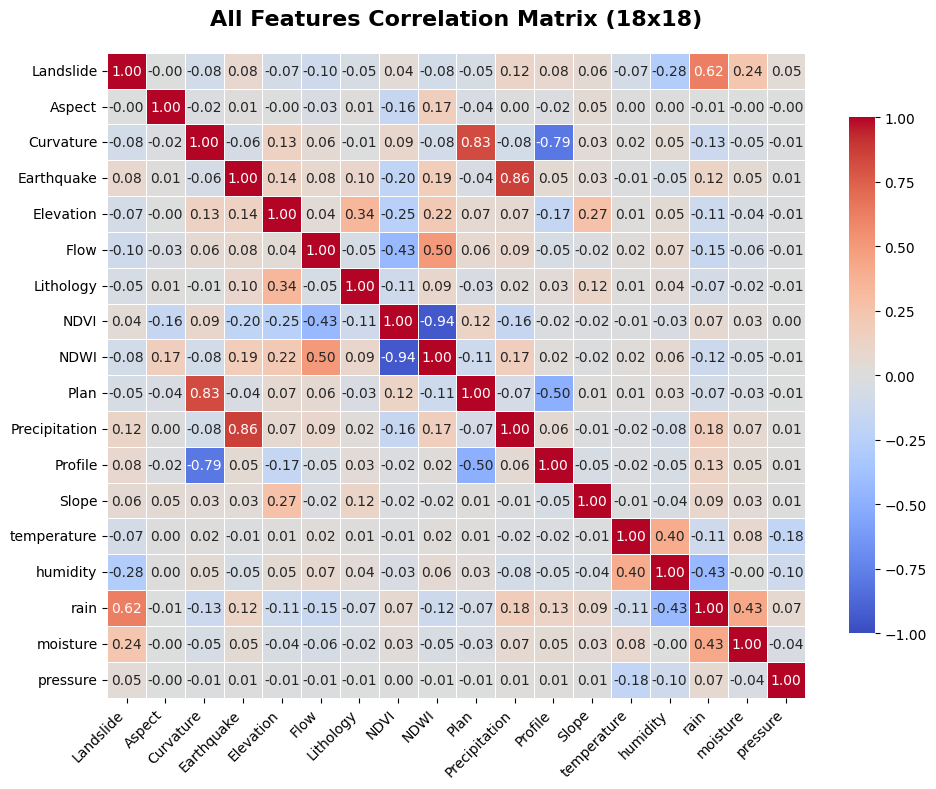

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

if 'Lithology' in df.columns and df['Lithology'].dtype == 'object':
    from sklearn.preprocessing import LabelEncoder
    df['Lithology'] = LabelEncoder().fit_transform(df['Lithology'].astype(str))

corr_matrix = df.corr(numeric_only=True)


plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,            # Values grid par dikhane ke liye
    fmt=".2f",             # Decimal ke baad 2 digits
    cmap='coolwarm',       # Red = High Positive, Blue = High Negative
    vmax=1, vmin=-1,
    linewidths=0.5,
    cbar_kws={"shrink": .8}
)

plt.title('All Features Correlation Matrix (18x18)', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

# X = Input Features (Landslide column hata kar)
# y = Target Variable (Landslide column)
X = df.drop(columns=['Landslide'])
y = df['Landslide']

# 80% Train, 20% Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

Train size: 152712 | Test size: 38178


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

# 1. XGBoost Model Define & Train
model = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

# 2. Predictions
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# 3. Model Evaluation
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_proba))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     36247
           1       0.98      0.96      0.97      1931

    accuracy                           1.00     38178
   macro avg       0.99      0.98      0.99     38178
weighted avg       1.00      1.00      1.00     38178

ROC-AUC Score: 0.9997209862129414


In [ ]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, roc_auc_score

# 1. Model Define
lgb_model = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    verbose=-1  # Clean console output ke liye
)

# 2. Model Train
lgb_model.fit(X_train, y_train)

# 3. Prediction & Evaluation
y_pred_lgb = lgb_model.predict(X_test)
y_proba_lgb = lgb_model.predict_proba(X_test)[:, 1]

print("--- LightGBM Performance ---")
print(classification_report(y_test, y_pred_lgb))
print("ROC-AUC Score:", roc_auc_score(y_test, y_proba_lgb))

--- LightGBM Performance ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     36247
           1       0.99      0.96      0.97      1931

    accuracy                           1.00     38178
   macro avg       0.99      0.98      0.99     38178
weighted avg       1.00      1.00      1.00     38178

ROC-AUC Score: 0.9997495748036478


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# 1. Model Define
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,       # Overfitting rokne ke liye depth limit
    random_state=42,
    n_jobs=-1           # Fast processing ke liye CPU cores use karega
)

# 2. Model Train
rf_model.fit(X_train, y_train)

# 3. Prediction & Evaluation
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print("--- Random Forest Performance ---")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC Score:", roc_auc_score(y_test, y_proba_rf))

--- Random Forest Performance ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     36247
           1       0.99      0.96      0.97      1931

    accuracy                           1.00     38178
   macro avg       0.99      0.98      0.99     38178
weighted avg       1.00      1.00      1.00     38178

ROC-AUC Score: 0.9989581094566415


In [ ]:
!pip install catboost
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, roc_auc_score

# 1. Model Define
cat_model = CatBoostClassifier(
    iterations=200,
    learning_rate=0.1,
    random_state=42,
    verbose=0  # Logs hide karne ke liye
)

# 2. Model Train
cat_model.fit(X_train, y_train)

# 3. Prediction & Evaluation
y_pred_cat = cat_model.predict(X_test)
y_proba_cat = cat_model.predict_proba(X_test)[:, 1]

print("--- CatBoost Performance ---")
print(classification_report(y_test, y_pred_cat))
print("ROC-AUC Score:", roc_auc_score(y_test, y_proba_cat))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.2 MB/s eta 0:00:00
--- CatBoost Performance ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     36247
           1       0.98      0.96      0.97      1931

    accuracy                           1.00     38178
   macro avg       0.99      0.98      0.98     38178
weighted avg       1.00      1.00      1.00     38178

ROC-AUC Score: 0.9996643233689928


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

# 1. XGBoost Model Define & Train
model = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

# 2. Predictions
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

custom_threshold = 0.11
y_pred_high_recall = (y_proba >= custom_threshold).astype(int)

from sklearn.metrics import classification_report
print("--- Performance at Threshold 0.11 ---")
print(classification_report(y_test, y_pred_high_recall))

--- Performance at Threshold 0.11 ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     36247
           1       0.93      0.99      0.96      1931

    accuracy                           1.00     38178
   macro avg       0.96      0.99      0.98     38178
weighted avg       1.00      1.00      1.00     38178



In [ ]:
from sklearn.ensemble import VotingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, roc_auc_score

# 1. Base Models Define Karein
model1 = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
model2 = LGBMClassifier(n_estimators=100, learning_rate=0.1, random_state=42, verbose=-1)
model3 = CatBoostClassifier(iterations=200, learning_rate=0.1, random_state=42, verbose=0)

# 2. Soft Voting Ensemble Banayein
ensemble_model = VotingClassifier(
    estimators=[
        ('xgb', model1),
        ('lgb', model2),
        ('cat', model3)
    ],
    voting='soft'  # Probabilities ka average lene ke liye
)

# 3. Fit Model
ensemble_model.fit(X_train, y_train)

# 4. Predict Probabilities & Apply Custom Threshold (0.11)
y_proba_ensemble = ensemble_model.predict_proba(X_test)[:, 1]

custom_threshold = 0.11
y_pred_ensemble = (y_proba_ensemble >= custom_threshold).astype(int)

# 5. Evaluate Performance
print("--- Ensemble Model Performance (Threshold = 0.11) ---")
print(classification_report(y_test, y_pred_ensemble))
print("ROC-AUC Score:", roc_auc_score(y_test, y_proba_ensemble))

--- Ensemble Model Performance (Threshold = 0.11) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     36247
           1       0.93      0.99      0.96      1931

    accuracy                           1.00     38178
   macro avg       0.97      0.99      0.98     38178
weighted avg       1.00      1.00      1.00     38178

ROC-AUC Score: 0.9997403024421443


In [ ]:
pip install gradio joblib

In [ ]:
import gradio as gr
import numpy as np
import pandas as pd

# 1. Prediction Function Banayein
def predict_landslide(Aspect, Earthquake, Elevation, Flow, Lithology,
                      NDVI, NDWI, Plan, Precipitation, Profile, Slope):

    # Input values ko DataFrame me Convert Karein (Same Column Sequence)
    input_data = pd.DataFrame([[
        Aspect, Earthquake, Elevation, Flow, Lithology,
        NDVI, NDWI, Plan, Precipitation, Profile, Slope
    ]], columns=[
        'Aspect', 'Earthquake', 'Elevation', 'Flow', 'Lithology',
        'NDVI', 'NDWI', 'Plan', 'Precipitation', 'Profile', 'Slope'
    ])

    # Ensemble Model se Probability Predict Karein
    # (Note: 'ensemble' aapke trained model variable ka naam hona chahiye)
    prob = ensemble.predict_proba(input_data)[0][1]

    # Custom Threshold (0.11) Apply Karein
    if prob >= 0.11:
        result = f"⚠️ HIGH LANDSLIDE RISK DETECTED!\nRisk Probability: {prob*100:.2f}%"
    else:
        result = f"✅ SAFE ZONE (LOW RISK)\nRisk Probability: {prob*100:.2f}%"

    return result

# 2. Gradio Web Interface Layout Banayein
interface = gr.Interface(
    fn=predict_landslide,
    inputs=[
        gr.Number(label="Aspect (Degrees)", value=180.0),
        gr.Number(label="Earthquake Intensity", value=0.0),
        gr.Number(label="Elevation (Meters)", value=1200.0),
        gr.Number(label="Flow Accumulation", value=150.0),
        gr.Number(label="Lithology (Class Code)", value=1),
        gr.Slider(-1.0, 1.0, value=0.25, label="NDVI (Vegetation Index)"),
        gr.Slider(-1.0, 1.0, value=-0.1, label="NDWI (Water Index)"),
        gr.Number(label="Plan Curvature", value=0.01),
        gr.Number(label="Precipitation (mm)", value=250.0),
        gr.Number(label="Profile Curvature", value=-0.02),
        gr.Number(label="Slope (Degrees)", value=35.0)
    ],
    outputs=gr.Textbox(label="Prediction Result", lines=3),
    title="🌋 Landslide Early Warning System",
    description="Custom terrain and hydrological parameters enter karke landslide risk predict karein."
)

# 3. Web UI Launch Karein
interface.launch(share=True)  # share=True se 72 hours ke liye public link mil jayega

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://46228509254514becc.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
df.head()

,Landslide,Aspect,Curvature,Earthquake,Elevation,Flow,Lithology,NDVI,NDWI,Plan,Precipitation,Profile,Slope,temperature,humidity,rain,moisture,pressure
0,0,2.000000,3.333333,1.666667,4.000000,2.666667,2.333333,3.000000,2.666667,3.000000,2.666667,2.666667,2.333333,18.212550,84.334223,26668.91667,31.248533,1017.904157
1,0,4.000000,2.666667,2.333333,2.000000,2.333333,1.666667,2.333333,2.666667,2.666667,4.333333,3.333333,2.000000,19.171867,73.905807,27103.16667,75.938967,1013.189603
2,0,3.000000,2.666667,3.000000,2.000000,2.000000,2.000000,2.666667,3.000000,3.000000,5.000000,3.333333,2.000000,22.785017,78.169993,26689.16667,51.231067,1016.092942
3,0,3.000000,2.666667,2.666667,2.666667,3.000000,1.333333,3.333333,2.666667,2.666667,5.000000,3.000000,2.666667,23.298793,81.467820,18678.75000,72.093500,1017.477364
4,0,2.666667,3.666667,2.333333,3.666667,1.666667,3.666667,2.666667,3.000000,3.000000,3.666667,2.000000,3.333333,22.453283,80.013987,26713.91667,53.482733,1013.225318


In [ ]:
pip install streamlit folium streamlit-folium joblib pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 92.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.9/536.9 kB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 108.1 MB/s eta 0:00:00


In [ ]:
import streamlit as st
import folium
from streamlit_folium import st_folium
import pandas as pd
import numpy as np
# Assuming 'ensemble' is your trained VotingClassifier model

st.set_page_config(layout="wide", page_title="Landslide Risk Live Map")
st.title("🌋 Real-Time Landslide Screening & Mapping System")

# Layout: Left side Map, Right side Input Features & Results
col1, col2 = st.columns([2, 1])

# Initialize default coordinates (Himalayan / Hilly Region)
if "lat" not in st.session_state:
    st.session_state.lat = 30.3165
    st.session_state.lon = 78.0322

with col1:
    st.subheader("📍 Click anywhere on the map to select a point")

    # Base Interactive Map
    m = folium.Map(location=[st.session_state.lat, st.session_state.lon], zoom_start=9)
    folium.TileLayer('stamenterrain', attr='Stamen Terrain').add_to(m) # Terrain view

    # Click Event Capture
    map_data = st_folium(m, height=500, width=700)

    if map_data and map_data.get("last_clicked"):
        st.session_state.lat = map_data["last_clicked"]["lat"]
        st.session_state.lon = map_data["last_clicked"]["lng"]

with col2:
    st.subheader("⛰️ Location Parameters")
    st.write(f"**Latitude:** {st.session_state.lat:.4f}")
    st.write(f"**Longitude:** {st.session_state.lon:.4f}")

    # Feature Inputs (In a real system, these can be auto-fetched using DEM/Satellite APIs)
    slope = st.slider("Slope (Degrees)", 0.0, 60.0, 35.0)
    precip = st.slider("Precipitation (mm)", 0.0, 500.0, 250.0)
    ndvi = st.slider("NDVI (Vegetation Index)", -1.0, 1.0, 0.15)
    elevation = st.number_input("Elevation (m)", value=1500.0)

    # Rest of default parameters
    aspect = 180.0
    earthquake = 0.0
    flow = 150.0
    lithology = 1
    ndwi = -0.1
    plan = 0.01
    profile = -0.02

    # Trigger Prediction
    if st.button("🔍 Analyze Landslide Risk", type="primary"):
        input_df = pd.DataFrame([[
            aspect, earthquake, elevation, flow, lithology,
            ndvi, ndwi, plan, precip, profile, slope
        ]], columns=[
            'Aspect', 'Earthquake', 'Elevation', 'Flow', 'Lithology',
            'NDVI', 'NDWI', 'Plan', 'Precipitation', 'Profile', 'Slope'
        ])

        # Predict using Ensemble Model & Custom Threshold (0.11)
        prob = ensemble.predict_proba(input_df)[0][1]

        st.divider()
        if prob >= 0.11:
            st.error(f"🚨 **HIGH RISK ZONE**\nProbability: {prob*100:.2f}%")
            color = "red"
        else:
            st.success(f"✅ **SAFE ZONE**\nProbability: {prob*100:.2f}%")
            color = "green"

        # Re-render map with risk marker
        res_map = folium.Map(location=[st.session_state.lat, st.session_state.lon], zoom_start=11)
        folium.Marker(
            [st.session_state.lat, st.session_state.lon],
            popup=f"Risk: {prob*100:.1f}%",
            icon=folium.Icon(color=color, icon="warning" if color=="red" else "info-sign")
        ).add_to(res_map)

        with col1:
            st.write("### Updated Risk Map:")
            st_folium(res_map, height=500, width=700)

2026-09-03 08:10:32.151 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-03 08:10:32.154 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-03 08:10:32.155 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-03 08:10:32.228 
  command:

    streamlit run /usr/local/lib/python3.13/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-09-03 08:10:32.229 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-03 08:10:32.232 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-03 08:10:32.233 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-03 08:10:32.234 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running 

In [ ]:
!streamlit run app.py

Usage: streamlit run [OPTIONS] [TARGET] [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: app.py


In [ ]:
!git config --global user.name "saurabhsinghyadavgit"
!git config --global user.email "saurabhsinghyadav8210@gmail.com"

In [ ]:
!git clone https://github.com/saurabhsinghyadavgit/land-sliding.git

Cloning into 'land-sliding'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.


In [ ]:
!ls /content

 catboost_info	    landslide_data		       land-sliding
'kaggle (7).json'   landslide-data-large-numeric.zip   sample_data


In [ ]:
%cd /content/land-sliding

/content/land-sliding
